In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
dataset= pd.read_csv("/content/test.csv")
dataset.shape
dataset.info()
dataset.describe()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,38881,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,30191,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,40640,19,Female,MCA,Civil,4.91,0,1,1,5,47,5,0,3,Not Placed
4996,46999,20,Male,B.Tech,ECE,6.82,2,3,5,7,76,6,2,0,Placed
4997,3816,20,Male,BCA,IT,5.80,0,3,6,7,56,6,2,2,Not Placed
4998,41368,23,Female,B.Tech,IT,7.67,1,4,7,6,67,4,2,0,Placed


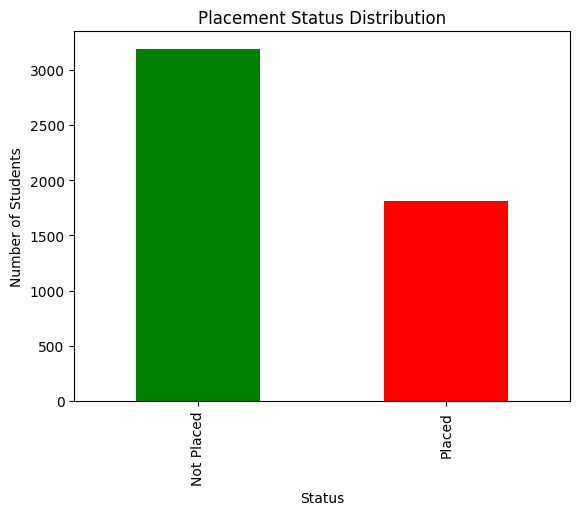

In [13]:

dataset.isnull().sum()
dataset.duplicated().sum()
dataset['Placement_Status'].value_counts()
dataset['Placement_Status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Placement Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Students')
plt.show()



In [15]:
dataset['Placement_Numeric'] = dataset['Placement_Status'].map({'Placed': 1, 'Not Placed': 0})
dataset[['Placement_Status', 'Placement_Numeric']].head()

,Placement_Status,Placement_Numeric
0,Placed,1
1,Not Placed,0
2,Not Placed,0
3,Placed,1
4,Not Placed,0


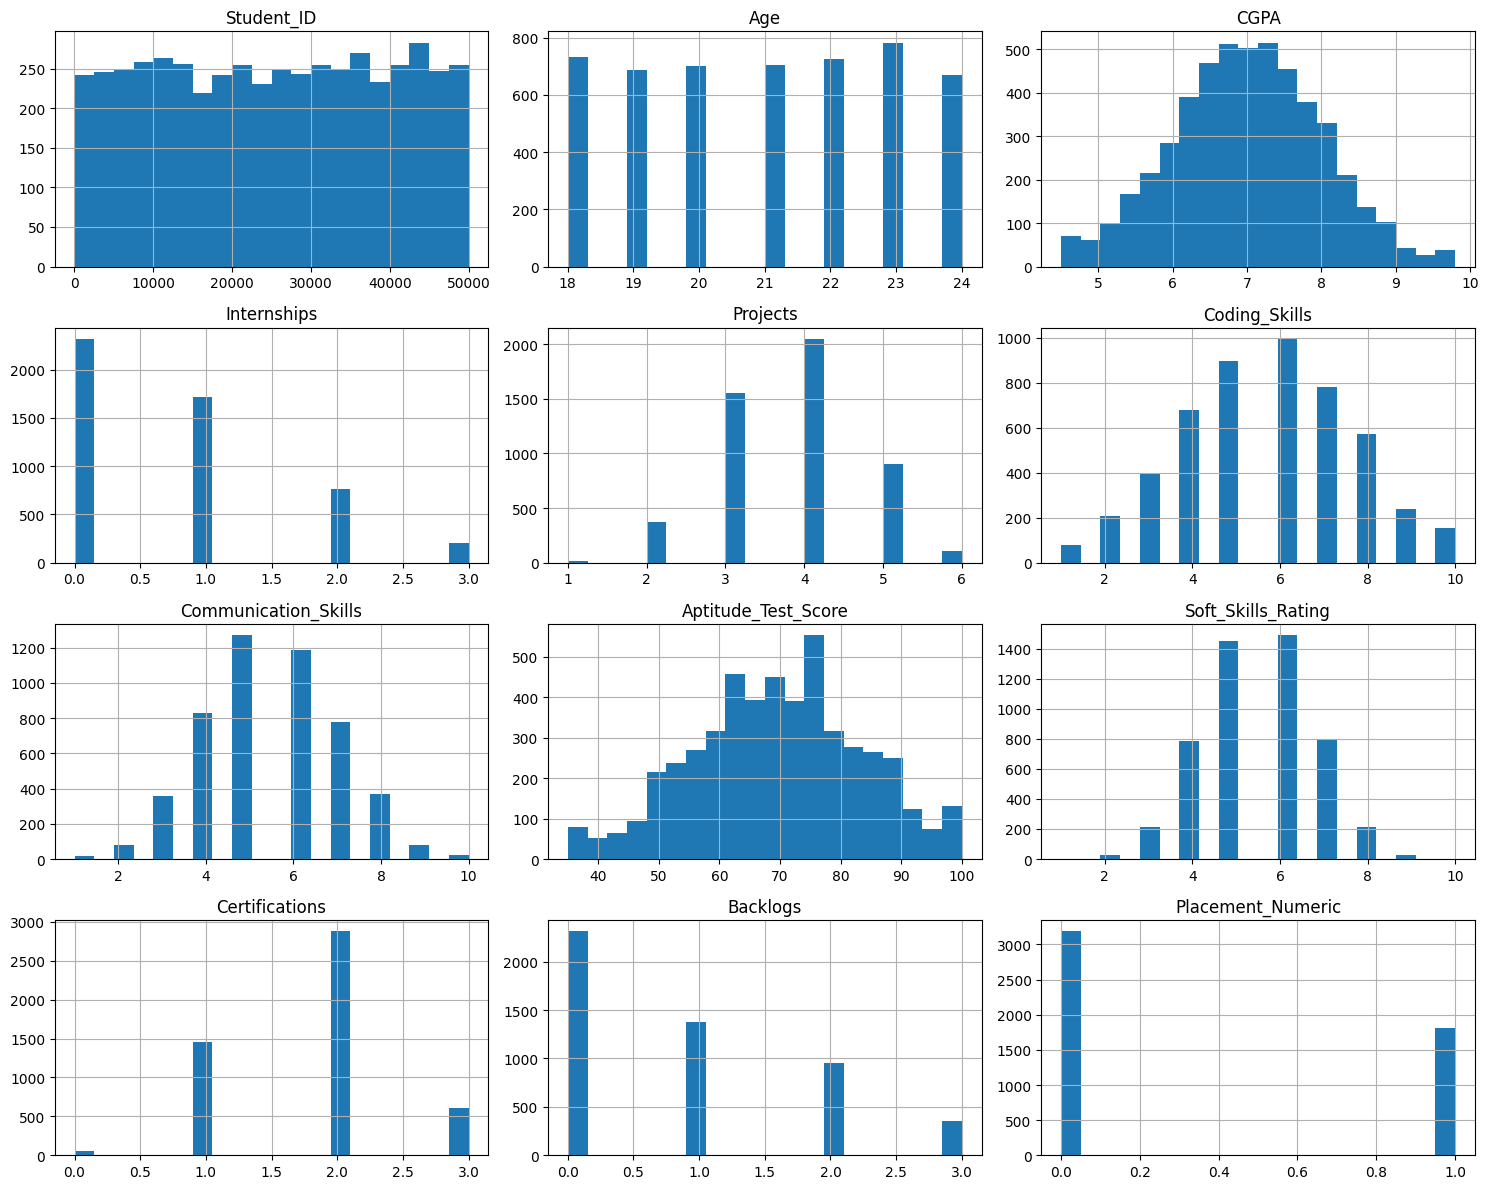

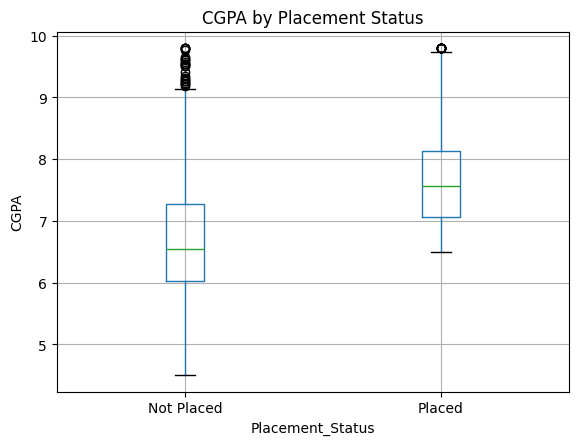

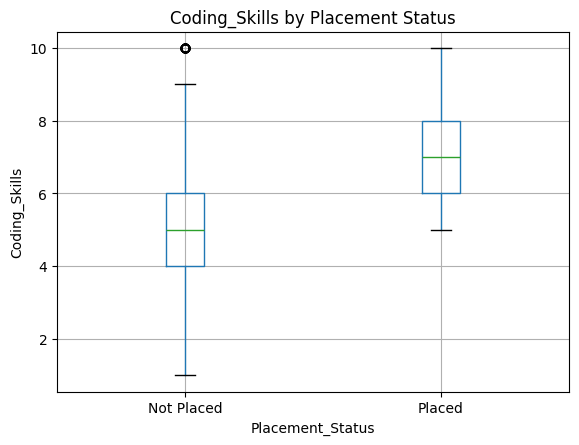

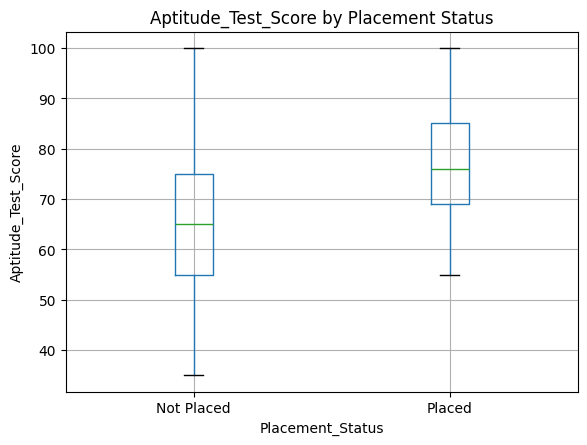

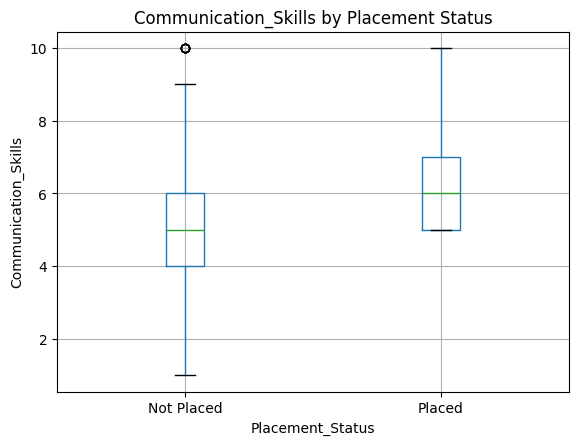

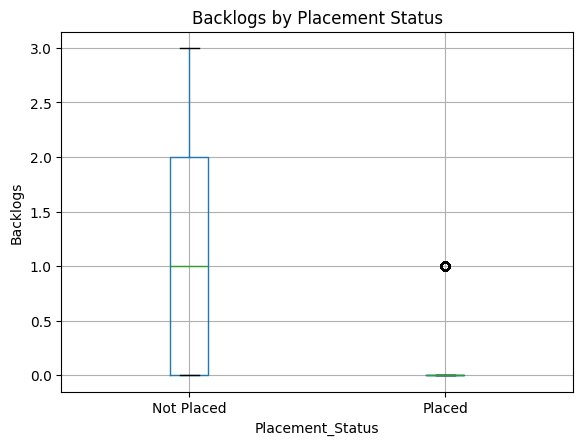

In [19]:
dataset.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

dataset.boxplot(column='CGPA', by='Placement_Status')
plt.title('CGPA by Placement Status')
plt.suptitle('')
plt.ylabel('CGPA')
plt.show()

dataset.boxplot(column='Coding_Skills', by='Placement_Status')
plt.title('Coding_Skills by Placement Status')
plt.suptitle('')
plt.ylabel('Coding_Skills')
plt.show()



dataset.boxplot(column='Aptitude_Test_Score', by='Placement_Status')
plt.title('Aptitude_Test_Score by Placement Status')
plt.suptitle('')
plt.ylabel('Aptitude_Test_Score')
plt.show()

dataset.boxplot(column='Communication_Skills', by='Placement_Status')
plt.title('Communication_Skills by Placement Status')
plt.suptitle('')
plt.ylabel('Communication_Skills')
plt.show()

dataset.boxplot(column='Backlogs', by='Placement_Status')
plt.title('Backlogs by Placement Status')
plt.suptitle('')
plt.ylabel('Backlogs')
plt.show()


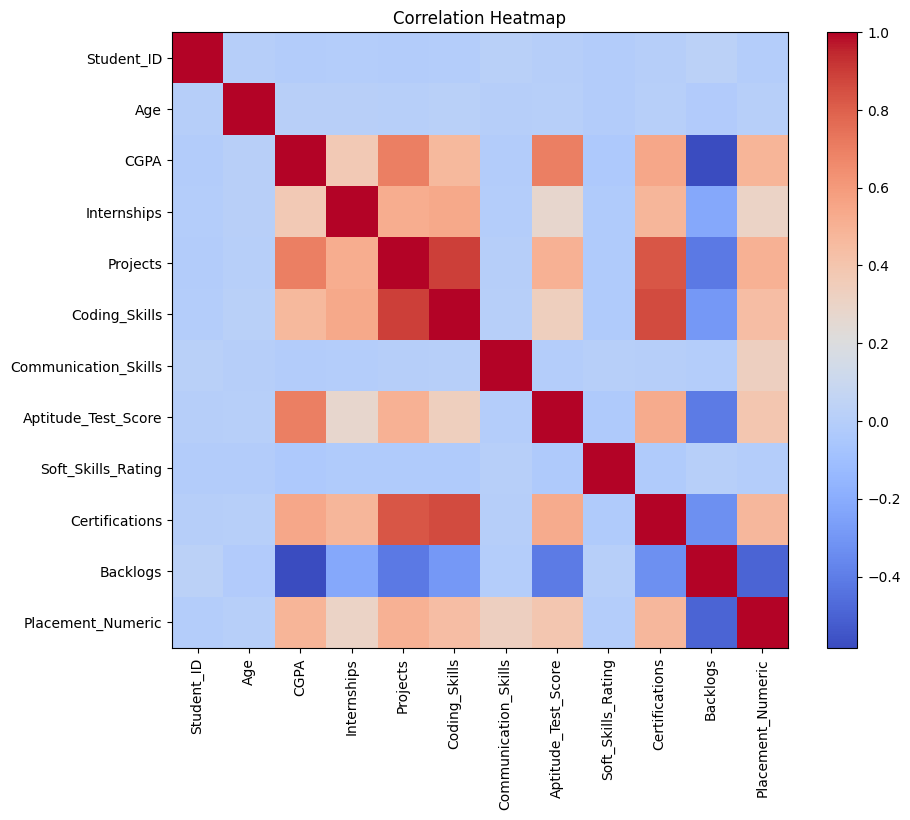

,Placement_Numeric
Placement_Numeric,1.000000
Projects,0.498994
CGPA,0.481313
Certifications,0.469516
Coding_Skills,0.440927
Aptitude_Test_Score,0.388431
Communication_Skills,0.330025
Internships,0.303489
Age,0.005450
Soft_Skills_Rating,-0.007282


In [24]:
numeric_cols = dataset.select_dtypes(include=[np.number])
correlation = numeric_cols.corr()
correlation
plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation)), correlation.columns)
plt.title('Correlation Heatmap')
plt.show()
correlation['Placement_Numeric'].sort_values(ascending=False)



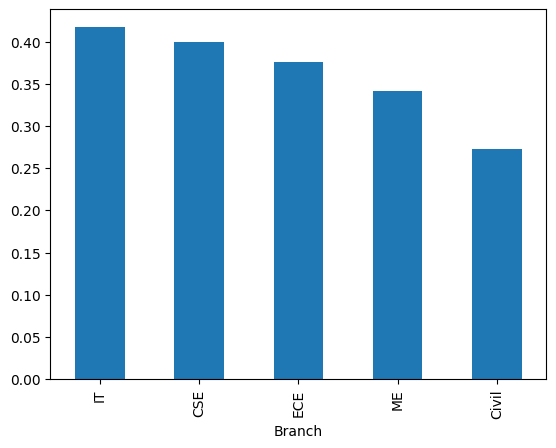

In [27]:
branch_rates = dataset.groupby('Branch')['Placement_Numeric'].mean()
branch_rates_sorted = branch_rates.sort_values(ascending=False)
branch_rates_sorted.plot(kind='bar')
plt.show()

In [28]:
dataset.to_csv('/content/placement_data_cleaned.csv', index=False)